# Fraud Detection — Credit Card Transactions

**Research question:** Can we detect fraudulent credit card transactions from anonymized transaction features, while explicitly managing the precision/recall tradeoff — where missing a fraud (false negative) and wrongly blocking a legitimate transaction (false positive) carry very different real-world costs?

**Dataset:** Credit Card Fraud Detection (ULB / Machine Learning Group, Université Libre de Bruxelles, in collaboration with Worldline) — [Kaggle link](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). Contains 284,807 credit card transactions made by European cardholders over two days in September 2013, of which 492 (0.172%) are fraudulent. All features except `Time` and `Amount` (`V1`–`V28`) are PCA-transformed for confidentiality. `Time` is seconds elapsed since the first transaction; `Amount` is the transaction value and can support cost-sensitive learning. The dataset authors explicitly recommend AUPRC over accuracy given the class imbalance.

**Citation:**
> Dal Pozzolo, A., Caelen, O., Johnson, R.A., Bontempi, G. *Calibrating Probability with Undersampling for Unbalanced Classification.* IEEE CIDM, 2015.


In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Load data

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "creditcard.csv"))
print(df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud
['creditcard.csv']
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. EDA — class imbalance, nulls, duplicates

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
print("Nulls per column:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Nulls per column:
 0
Duplicate rows: 1081


Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


/tmp/ipykernel_10737/333858071.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Fraud (0)", "Fraud (1)"])


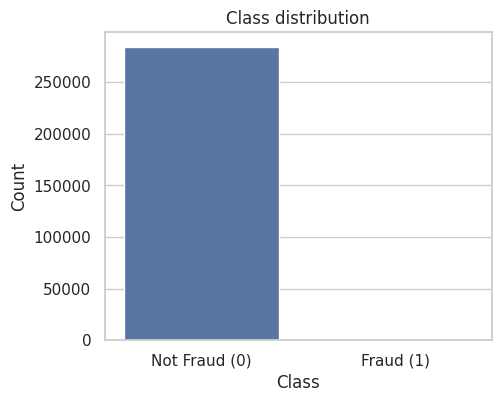

In [5]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

fig, ax = plt.subplots(figsize=(5,4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax)
ax.set_xticklabels(["Not Fraud (0)", "Fraud (1)"])
ax.set_ylabel("Count")
ax.set_title("Class distribution")
plt.show()


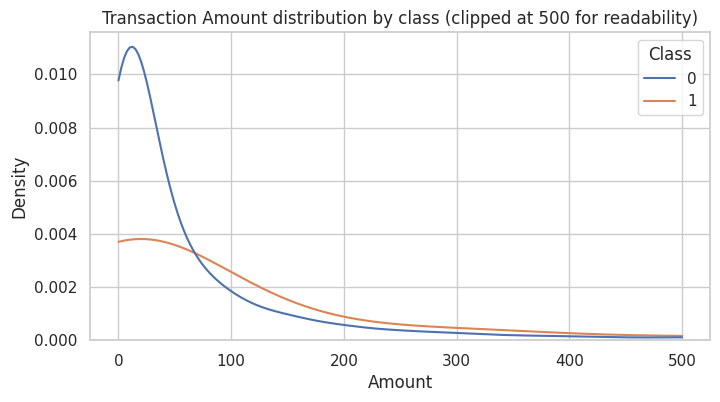

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
sns.kdeplot(data=df, x="Amount", hue="Class", common_norm=False, ax=ax, clip=(0, 500))
ax.set_title("Transaction Amount distribution by class (clipped at 500 for readability)")
plt.show()


## 3. Train/test split (stratified — critical given imbalance)

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())


Train fraud rate: 0.001729245759178389
Test fraud rate: 0.0017204452090867595


## 4. Baseline model — Logistic Regression

Wrapped in a `Pipeline` combining scaling and model training, ensuring that preprocessing is fitted only within each cross-validation split and preventing data leakage.



In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline_scores = cross_val_score(baseline_pipe, X_train, y_train, cv=cv, scoring="average_precision")
print("Baseline PR-AUC (CV):", baseline_scores.mean(), "+/-", baseline_scores.std())


Baseline PR-AUC (CV): 0.7571360842475147 +/- 0.05209634202750959


## 5. Model comparison — Random Forest, XGBoost

In [9]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": baseline_pipe,
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            random_state=RANDOM_STATE,
            scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
            eval_metric="logloss"
        ))
    ]),
}

results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
    results[name] = scores
    print(f"{name}: PR-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")


Logistic Regression: PR-AUC = 0.7571 +/- 0.0521
Random Forest: PR-AUC = 0.8395 +/- 0.0234
XGBoost: PR-AUC = 0.8489 +/- 0.0182


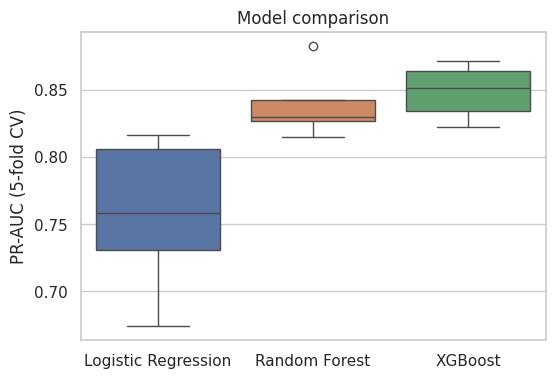

In [10]:
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=results_df, ax=ax)
ax.set_ylabel("PR-AUC (5-fold CV)")
ax.set_title("Model comparison")
plt.show()


## 6. Fit best model on full training set

In [11]:
best_model_name = results_df.mean().idxmax()
print("Best model:", best_model_name)

best_pipe = models[best_model_name]
best_pipe.fit(X_train, y_train)


Best model: XGBoost


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 7. Threshold selection — cost-sensitive decision

Instead of the default 0.5 cutoff, define an illustrative cost matrix and pick the threshold that minimizes expected cost.

- Cost of a **missed fraud** (false negative): assume avg. fraud amount lost, e.g. £100
- Cost of a **false alarm** (false positive): assume customer friction / manual review cost, e.g. £5

(Numbers are illustrative — swap in real business figures if available.)


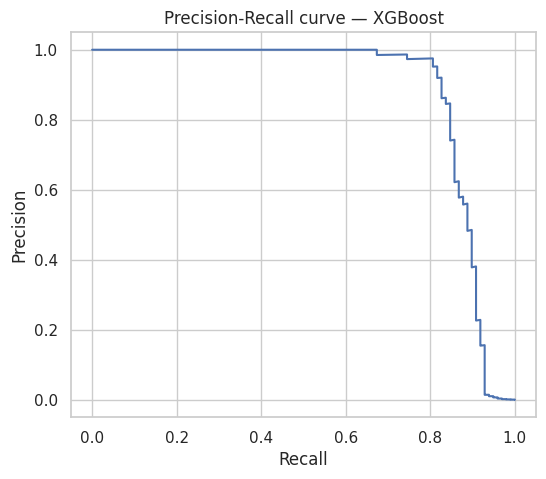

In [12]:
from sklearn.metrics import precision_recall_curve

y_scores = best_pipe.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(recall, precision)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall curve — {best_model_name}")
plt.show()


In [13]:
COST_FN = 100  # cost of a missed fraud
COST_FP = 5    # cost of a false alarm

costs = []
for t in thresholds:
    preds = (y_scores >= t).astype(int)
    fn = ((preds == 0) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)

costs = np.array(costs)
best_threshold = thresholds[np.argmin(costs)]
print("Best threshold (min expected cost):", best_threshold)
print("Min expected cost:", costs.min())


Best threshold (min expected cost): 0.011557806
Min expected cost: 1440


## 8. Final evaluation on held-out test set at chosen threshold

PR-AUC (test): 0.8790551796218563
              precision    recall  f1-score   support

           0     0.9998    0.9988    0.9993     56864
           1     0.5613    0.8878    0.6877        98

    accuracy                         0.9986     56962
   macro avg     0.7805    0.9433    0.8435     56962
weighted avg     0.9991    0.9986    0.9988     56962



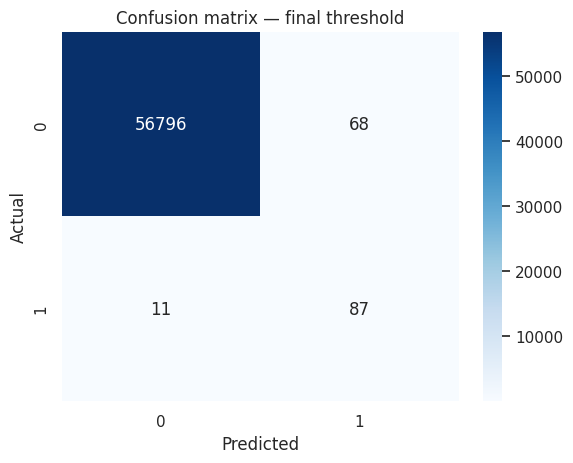

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

final_preds = (y_scores >= best_threshold).astype(int)

print("PR-AUC (test):", average_precision_score(y_test, y_scores))
print(classification_report(y_test, final_preds, digits=4))

cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — final threshold")
plt.show()


## 9. Error analysis

Look at the missed frauds (false negatives) — is there a pattern in `Amount` or specific PCA components?


In [15]:
fn_mask = (final_preds == 0) & (y_test.values == 1)
fn_cases = X_test[fn_mask]
print("Number of missed frauds:", fn_mask.sum())
fn_cases[["Time", "Amount"]].describe()


Number of missed frauds: 11


,Time,Amount
count,11.000000,11.000000
mean,75829.545455,174.790909
std,47863.853193,252.576912
min,472.000000,1.000000
25%,48673.000000,2.130000
50%,65728.000000,29.950000
75%,110352.000000,309.945000
max,152710.000000,635.100000


## 10. Save final pipeline

In [16]:
import joblib

joblib.dump(best_pipe, "fraud_model.joblib")
joblib.dump(best_threshold, "threshold.joblib")
print("Saved model and threshold.")

Saved model and threshold.


## 11. Limitations

- Features `V1`-`V28` are PCA-anonymized, limiting interpretability of individual drivers.
- Single static historical dataset. Thus, no concept drift / data recency handling.
- Cost matrix values (`COST_FN`, `COST_FP`) are illustrative and are not derived from real business figures.
